# Exploratory Data Analysis

The purpose of this notebook is to conduct a univariate analysis to examine variable distributions, identify potential data preprocessing steps and assess potential predictors for signs of complete or quasi-complete separation, which is critical for logistic regression classification tasks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import model_selection

In [2]:
# func for numerical variables EDA
def num_eda(Series, title=''): 
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.histplot(data=Series, color='tab:blue', ax=axes[0])
    hist_title = title + ' Distribution'
    axes[0].set_title(hist_title)
    
    sns.boxplot(data=Series, color='tab:blue', ax=axes[1], saturation=0.3)
    box_title = title + ' Boxplot'
    axes[1].set_title(box_title)
    
    plt.tight_layout()
    plt.show()
    stats = pd.DataFrame(Series.describe())
    return stats

In [3]:
# func for categorical variables EDA
def cat_eda(Series, title=''):
    plt.title(title)
    sns.barplot(data=Series.value_counts(), orient='h', color='tab:blue', saturation=0.3, legend='brief')
    plt.show()
    stats = pd.DataFrame({
        'Count': Series.value_counts(),
        'Prob': Series.value_counts(normalize=True)
             })
    return stats

In [4]:
# func for complete and quazi-complete separation check
def sep_check(data, x, hue, title=''):
    plt.title(title)
    sns.kdeplot(data=data, x=x, hue=hue, common_norm=False)
    plt.show()

In [5]:
data = pd.read_csv('data_cleaned.csv')
data.head()

,loan_status,loan_amnt,int_rate,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,delta_issue_earliest,term,emp_length,home_ownership,verification_status,purpose,initial_list_status
0,0,10000.0,11.44,117000.0,26.24,16.0,0.0,36369.0,41.8,25.0,0.0,0.0,8980,36 months,10+ years,RENT,Not Verified,vacation,w
1,0,8000.0,11.99,65000.0,22.05,17.0,0.0,20131.0,53.3,27.0,3.0,0.0,3836,36 months,4 years,MORTGAGE,Not Verified,debt_consolidation,f
2,0,15600.0,10.49,43057.0,12.79,13.0,0.0,11987.0,92.2,26.0,0.0,0.0,2710,36 months,< 1 year,RENT,Source Verified,credit_card,f
3,0,7200.0,6.49,54000.0,2.60,6.0,0.0,5472.0,21.5,13.0,0.0,0.0,2983,36 months,6 years,RENT,Not Verified,credit_card,f
4,1,24375.0,17.27,55000.0,33.95,13.0,0.0,24584.0,69.8,43.0,1.0,0.0,5145,60 months,9 years,MORTGAGE,Verified,credit_card,f


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340775 entries, 0 to 340774
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_status           340775 non-null  int64  
 1   loan_amnt             340775 non-null  float64
 2   int_rate              340775 non-null  float64
 3   annual_inc            340775 non-null  float64
 4   dti                   340775 non-null  float64
 5   open_acc              340775 non-null  float64
 6   pub_rec               340775 non-null  float64
 7   revol_bal             340775 non-null  float64
 8   revol_util            340775 non-null  float64
 9   total_acc             340775 non-null  float64
 10  mort_acc              340775 non-null  float64
 11  pub_rec_bankruptcies  340775 non-null  float64
 12  delta_issue_earliest  340775 non-null  int64  
 13  term                  340775 non-null  object 
 14  emp_length            340775 non-null  object 
 15  

## 1. Split on Train, Validation and Test Datasets

Before proceeding with the distribution analysis, I will split the dataset into training, validation and test sets to avoid data leakage. A 70:15:15 ratio will be used for the train, validatio and test sets. As the target variable is imbalanced, a stratified split will be applied to maintain consistent class proportions across the datasets.

In [6]:
y = data['loan_status']
X = data.iloc[:, 1:]

In [7]:
X_train, X_temp, y_train, y_temp = model_selection.train_test_split(X, y, test_size = 0.3, stratify=y, random_state = 42)

In [8]:
X_val, X_test, y_val, y_test = model_selection.train_test_split(X_temp, y_temp, test_size = 0.5, stratify=y_temp, random_state = 42)

In [9]:
print('Train Set Size (70%): ', len(X_train))
print('Validation Set Size (15%): ', len(X_val))
print('Test Set Size (15%): ', len(X_test))

Train Set Size (70%):  238542
Validation Set Size (15%):  51116
Test Set Size (15%):  51117


## 2. Univariate Analysis

I repeat the univariate analysis of the categorical variables because I want to evaluate all potential dummy variables after encoding and determine whether some categories can be combined through binning.

### 2.1. Target Variable

In [10]:
train = pd.concat([y_train, X_train], axis=1) #concat faetures and target variables in a single dataset for futue analysis

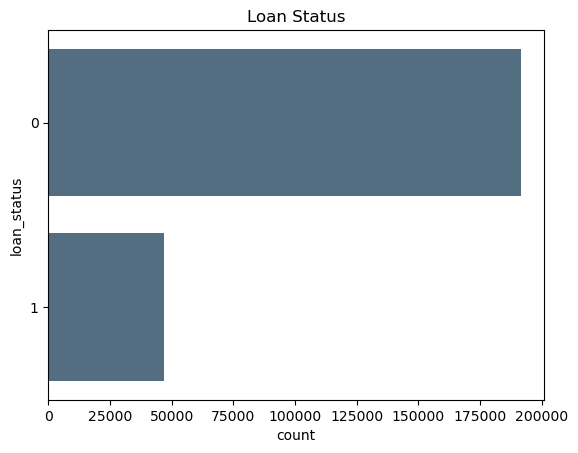

,Count,Prob
loan_status,,
0,191454,0.802601
1,47088,0.197399


In [11]:
cat_eda(train['loan_status'], title='Loan Status')

The target variable is imbalanced, with 19.7% of observations belonging to the positive class.

### 2.2. Numerical Predictors

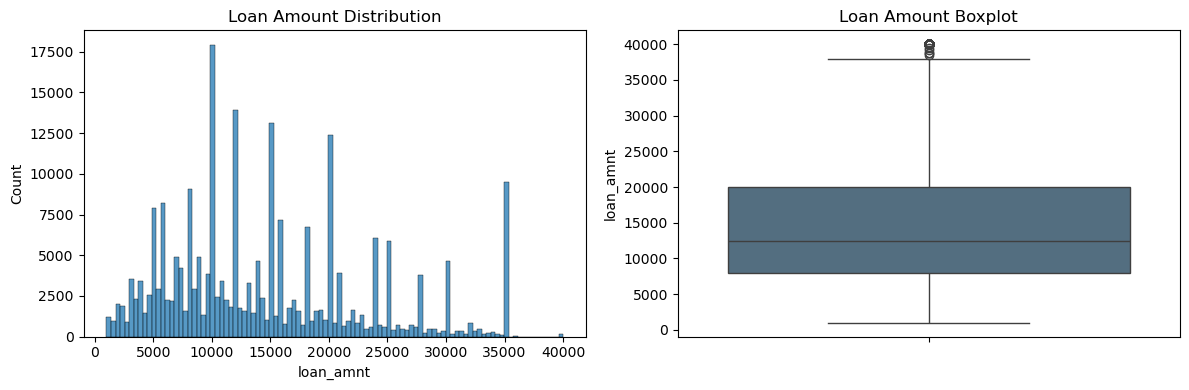

,loan_amnt
count,238542.000000
mean,14544.192427
std,8405.329094
min,1000.000000
25%,8000.000000
50%,12500.000000
75%,20000.000000
max,40000.000000


In [12]:
num_eda(X_train['loan_amnt'], title='Loan Amount')

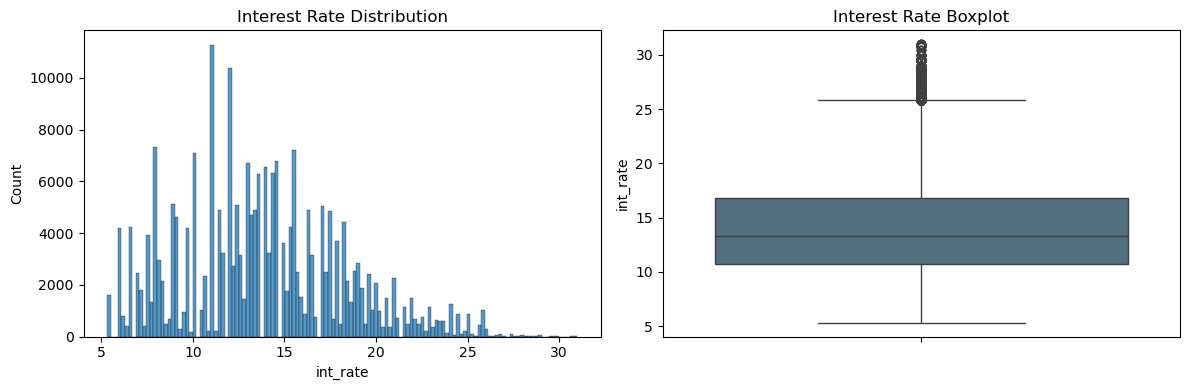

,int_rate
count,238542.000000
mean,13.797416
std,4.508009
min,5.320000
25%,10.740000
50%,13.350000
75%,16.780000
max,30.990000


In [13]:
num_eda(X_train['int_rate'], title='Interest Rate')

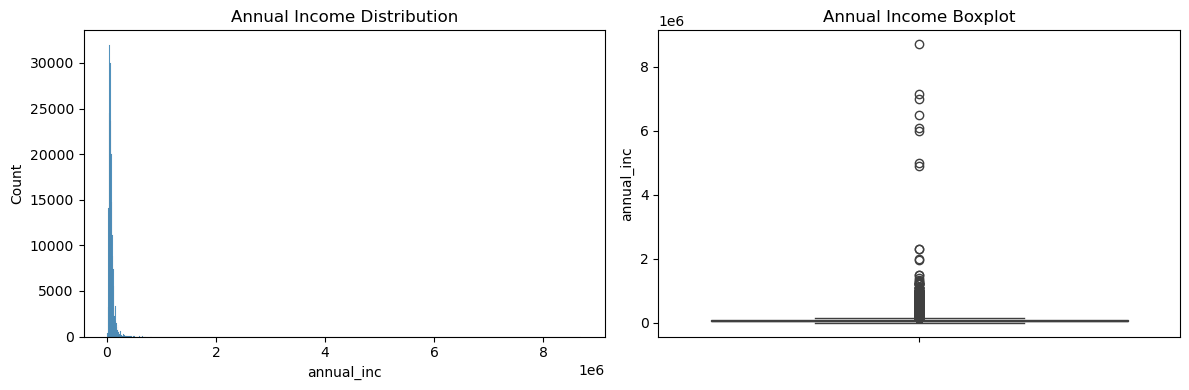

,annual_inc
count,2.385420e+05
mean,7.601605e+04
std,6.187426e+04
min,6.000000e+03
25%,4.700000e+04
50%,6.500000e+04
75%,9.000000e+04
max,8.706582e+06


In [14]:
num_eda(X_train['annual_inc'], title='Annual Income')

The distribution is highly right-skewed and requires a log transformation

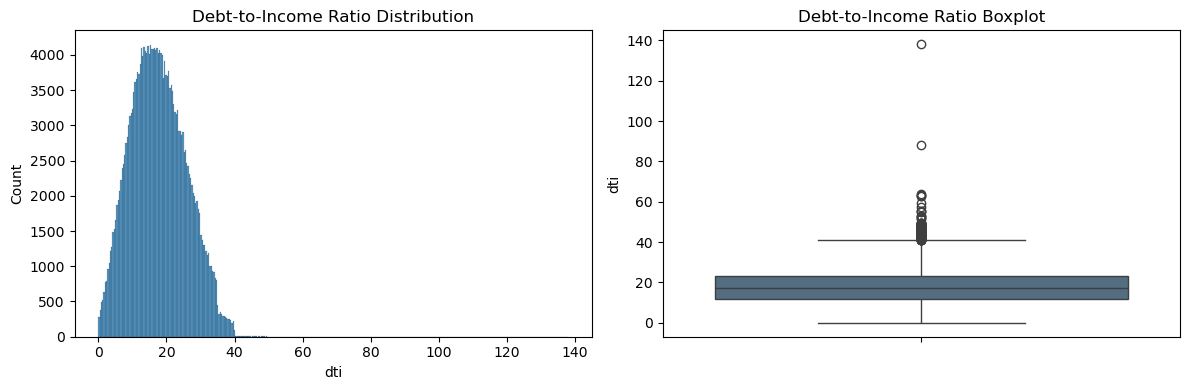

,dti
count,238542.000000
mean,17.680275
std,8.123926
min,0.000000
25%,11.600000
50%,17.210000
75%,23.360000
max,138.030000


In [15]:
num_eda(X_train['dti'], title='Debt-to-Income Ratio')

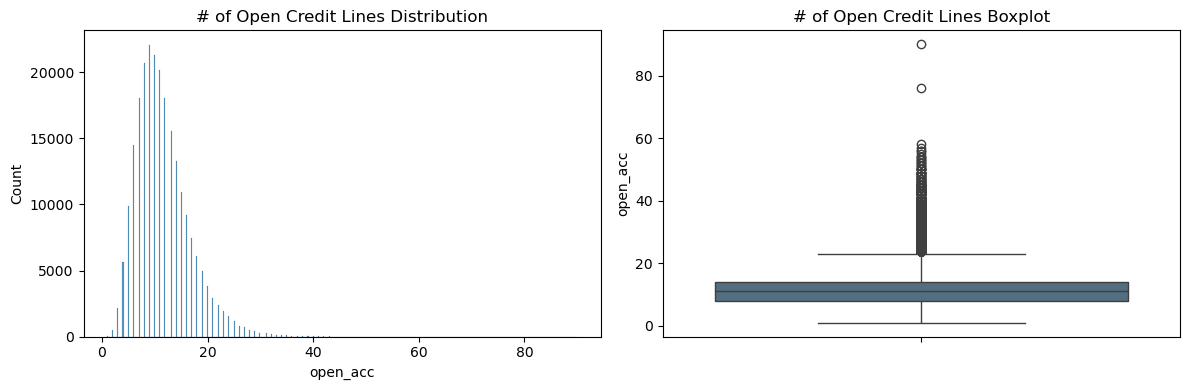

,open_acc
count,238542.000000
mean,11.587892
std,5.183066
min,1.000000
25%,8.000000
50%,11.000000
75%,14.000000
max,90.000000


In [16]:
num_eda(X_train['open_acc'], title='# of Open Credit Lines')

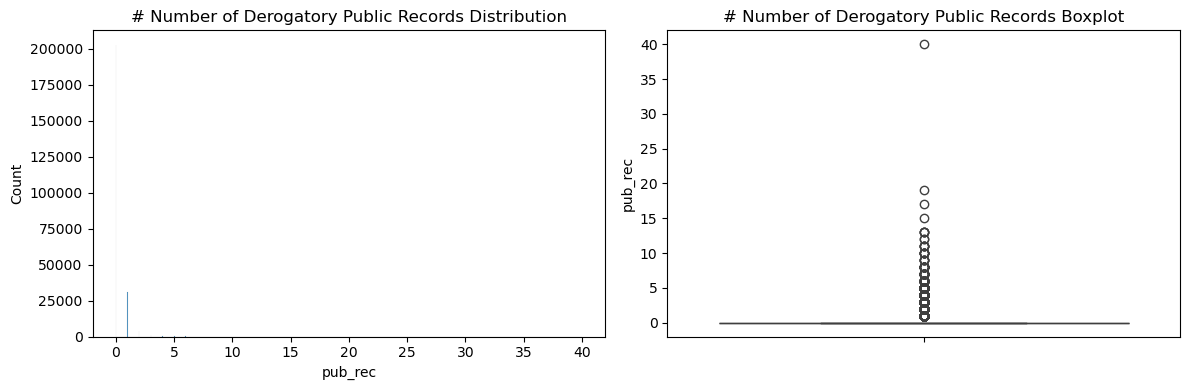

,pub_rec
count,238542.000000
mean,0.185649
std,0.526983
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,40.000000


In [17]:
num_eda(X_train['pub_rec'], title='# Number of Derogatory Public Records')

Since 75% of the observations have a value of zero, I will treat this variable as categorical and analyse the category distribution:

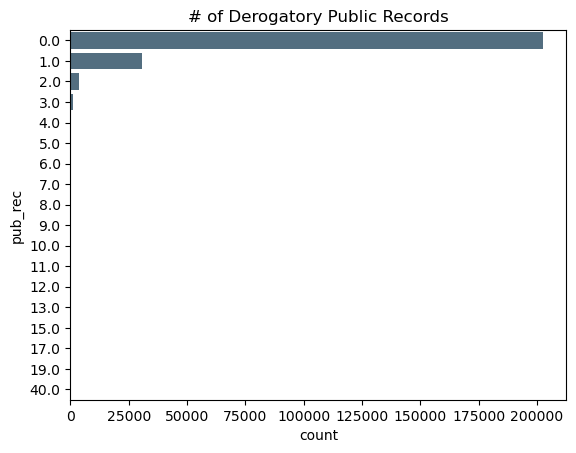

,Count,Prob
pub_rec,,
0.0,202495,0.848886
1.0,30864,0.129386
2.0,3530,0.014798
3.0,992,0.004159
4.0,342,0.001434
5.0,154,0.000646
6.0,81,0.000340
7.0,32,0.000134
8.0,25,0.000105


In [18]:
cat_eda(X_train['pub_rec'], title='# of Derogatory Public Records')

In [19]:
train[['pub_rec', 'loan_status']].groupby('pub_rec').agg('mean')

,loan_status
pub_rec,
0.0,0.195649
1.0,0.203635
2.0,0.226346
3.0,0.218750
4.0,0.266082
5.0,0.220779
6.0,0.271605
7.0,0.281250
8.0,0.160000


The probability of the positive class appears to increase with the number of records. Therefore, I will transform this variable into a binary feature (0 vs. >0 records) and use it as a predictor in the models

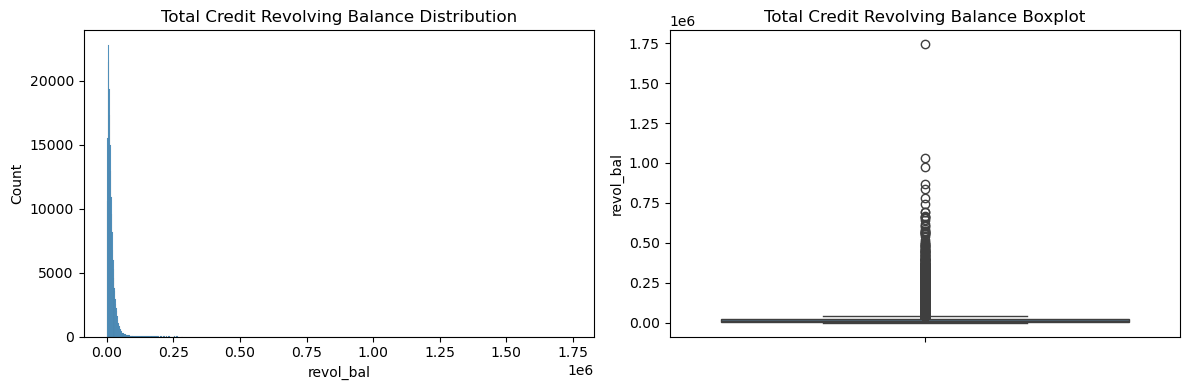

,revol_bal
count,2.385420e+05
mean,1.623722e+04
std,2.110673e+04
min,0.000000e+00
25%,6.297000e+03
50%,1.149900e+04
75%,2.003200e+04
max,1.743266e+06


In [20]:
num_eda(X_train['revol_bal'], title='Total Credit Revolving Balance')

Right-skewed variable, need to apply log transformation

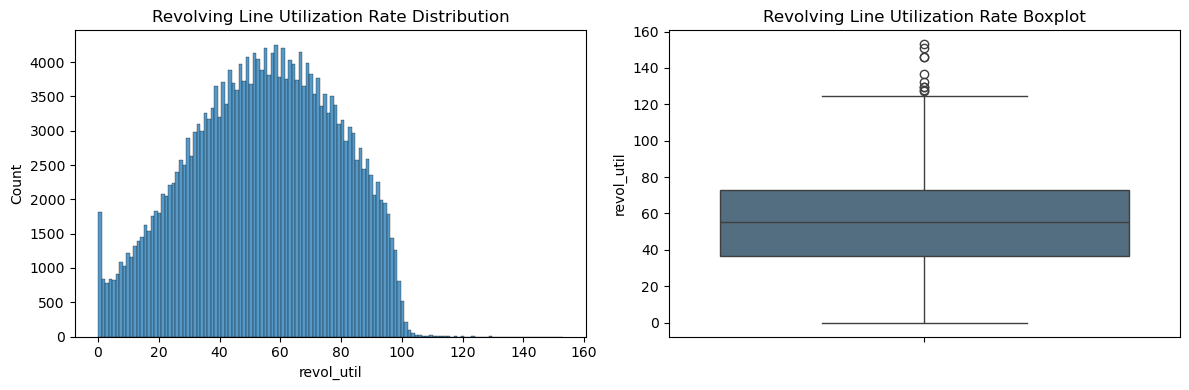

,revol_util
count,238542.000000
mean,54.348911
std,23.928665
min,0.000000
25%,36.800000
50%,55.300000
75%,73.000000
max,153.000000


In [21]:
num_eda(X_train['revol_util'], title='Revolving Line Utilization Rate')

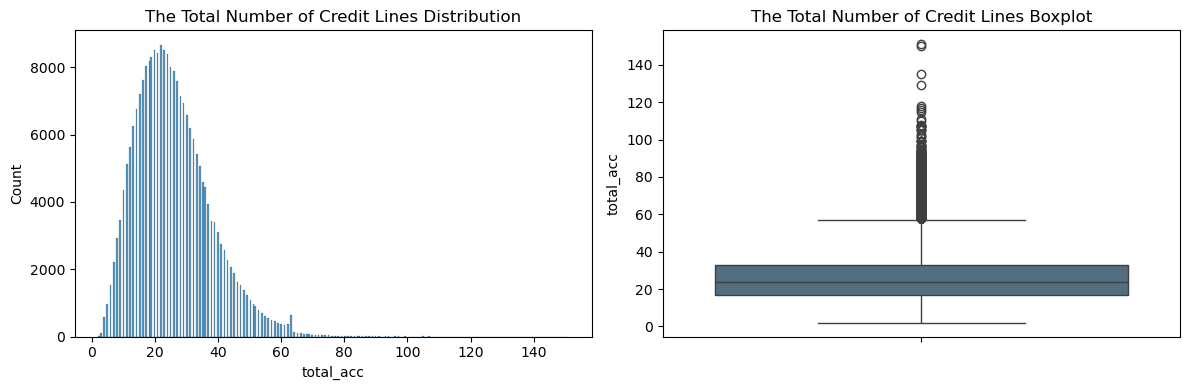

,total_acc
count,238542.000000
mean,25.835048
std,11.904288
min,2.000000
25%,17.000000
50%,24.000000
75%,33.000000
max,151.000000


In [22]:
num_eda(X_train['total_acc'], title='The Total Number of Credit Lines')

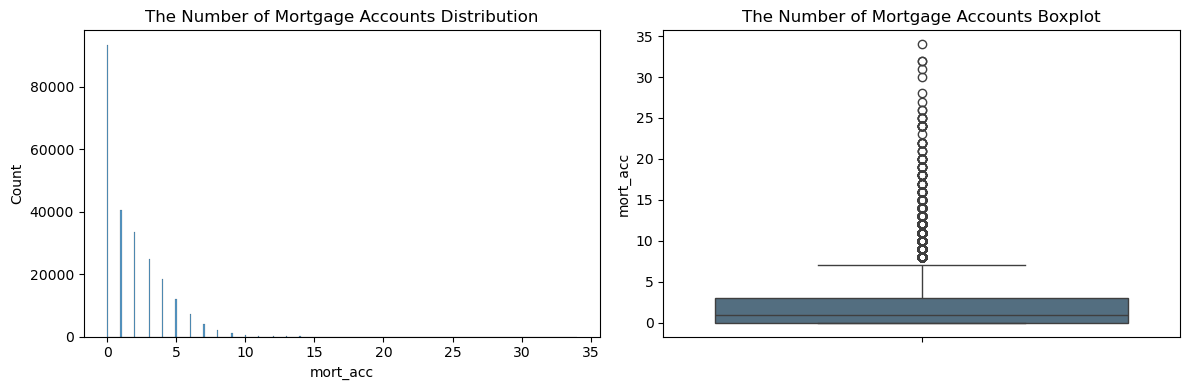

,mort_acc
count,238542.000000
mean,1.806156
std,2.148807
min,0.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,34.000000


In [23]:
num_eda(X_train['mort_acc'], title='The Number of Mortgage Accounts')

Pehaps, this variable would be more useful as a binary indicator, let's look at the probabilities

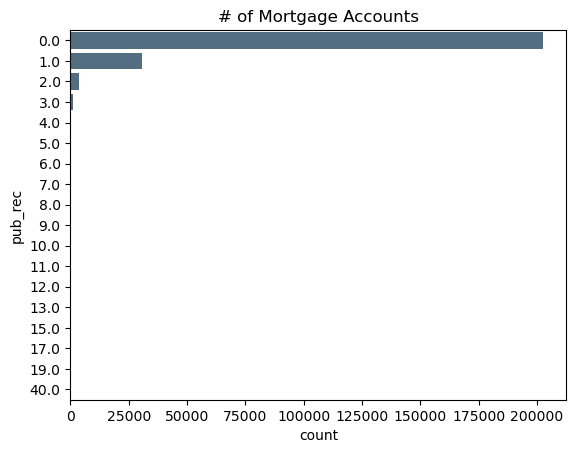

,Count,Prob
pub_rec,,
0.0,202495,0.848886
1.0,30864,0.129386
2.0,3530,0.014798
3.0,992,0.004159
4.0,342,0.001434
5.0,154,0.000646
6.0,81,0.000340
7.0,32,0.000134
8.0,25,0.000105


In [24]:
cat_eda(X_train['pub_rec'], title='# of Mortgage Accounts')

The proportion of customers with more than 1 mortgage account is small. From a business perspective it is makes more sense to treat this variable as binary, indicating whether a customer has a mortgage account or not.

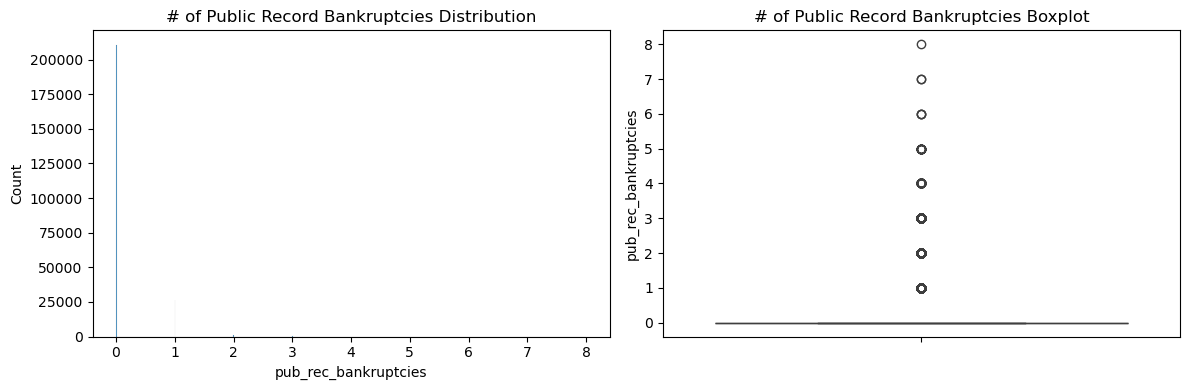

,pub_rec_bankruptcies
count,238542.000000
mean,0.125454
std,0.361596
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,8.000000


In [21]:
num_eda(X_train['pub_rec_bankruptcies'], title='# of Public Record Bankruptcies')

75% of customers have no public bankruptcy records. This variable may be more informative as a binary indicator reflecting whether a customer has a history of bankruptcy. Let's look at the distribution of the categories:

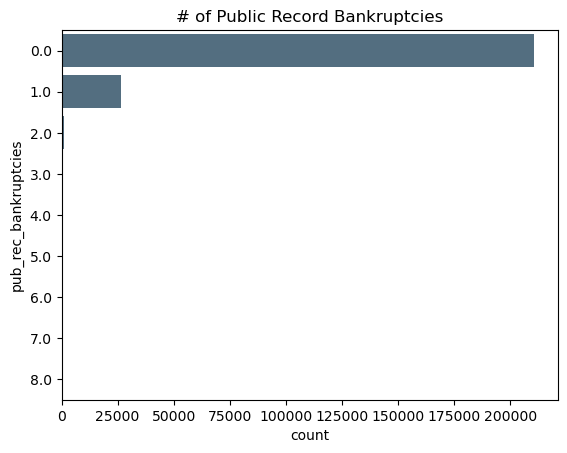

,Count,Prob
pub_rec_bankruptcies,,
0.0,210539,0.882608
1.0,26501,0.111096
2.0,1194,0.005005
3.0,232,0.000973
4.0,49,0.000205
5.0,21,0.000088
6.0,3,0.000013
7.0,2,0.000008
8.0,1,0.000004


In [14]:
cat_eda(X_train['pub_rec_bankruptcies'], title='# of Public Record Bankruptcies')

In [20]:
train[['pub_rec_bankruptcies', 'loan_status']].groupby('pub_rec_bankruptcies').agg('mean')

,loan_status
pub_rec_bankruptcies,
0.0,0.197317
1.0,0.196672
2.0,0.224456
3.0,0.189655
4.0,0.367347
5.0,0.095238
6.0,0.000000
7.0,0.000000
8.0,1.000000


There appears to be little difference between customers with 0 and 1 bankruptcy records, as their probabilities are almost identical. But, given the business significance of this variable, I will convert it into a binary feature (0 vs. >0 bankruptcies) and use it in the models.

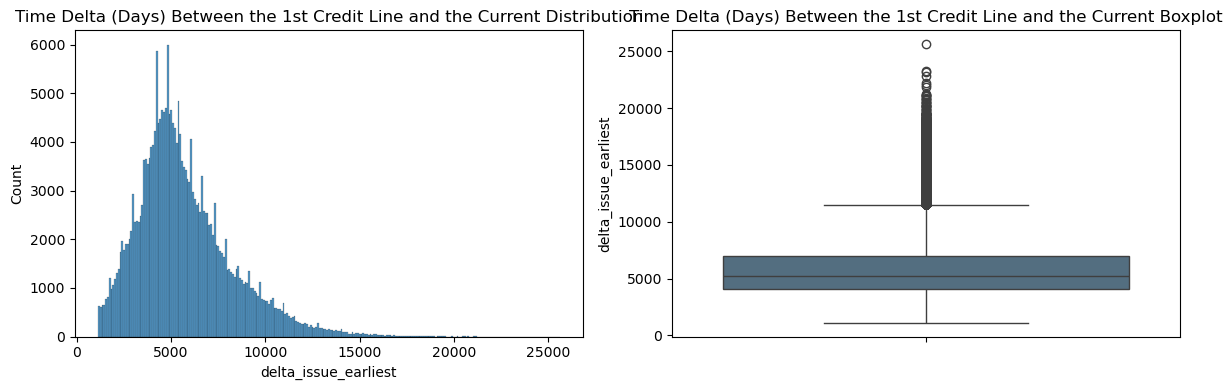

,delta_issue_earliest
count,238542.000000
mean,5737.362762
std,2538.833547
min,1124.000000
25%,4046.000000
50%,5264.000000
75%,7031.000000
max,25627.000000


In [24]:
num_eda(X_train['delta_issue_earliest'], title='Time Delta (Days) Between the 1st Credit Line and the Current')

### 2.3. Categorical Predictors

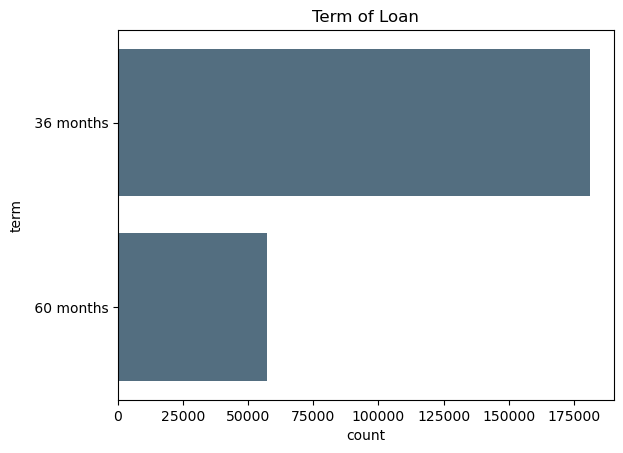

,Count,Prob
term,,
36 months,181306,0.760059
60 months,57236,0.239941


In [109]:
cat_eda(X_train['term'], 'Term of Loan')

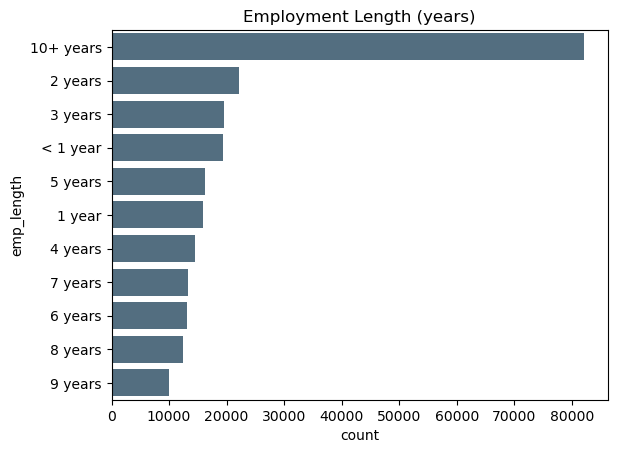

,Count,Prob
emp_length,,
10+ years,82079,0.344086
2 years,22150,0.092856
3 years,19492,0.081713
< 1 year,19341,0.081080
5 years,16316,0.068399
1 year,15946,0.066848
4 years,14435,0.060513
7 years,13297,0.055743
6 years,13069,0.054787


In [27]:
cat_eda(X_train['emp_length'], 'Employment Length (years)')

There are too many categories with low frequencies. I will regroup them into the buckets: ≤2 years of experience, 3–5 years, 6–9 years and 10+ years

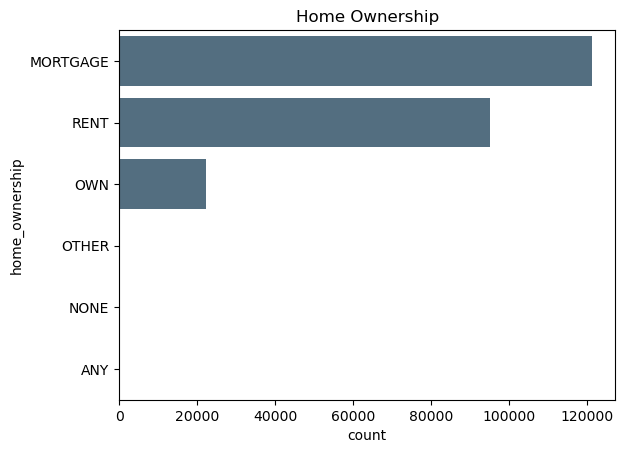

,Count,Prob
home_ownership,,
MORTGAGE,121159,0.507915
RENT,95109,0.398710
OWN,22235,0.093212
OTHER,20,0.000084
NONE,17,0.000071
ANY,2,0.000008


In [28]:
cat_eda(X_train['home_ownership'], 'Home Ownership')

The categories *Other*, *None* and *Any* are sparsely represented in the dataset. Creating individual dummy variables for these categories would add little predictive value and may increase model instability. I will group them into a single category.

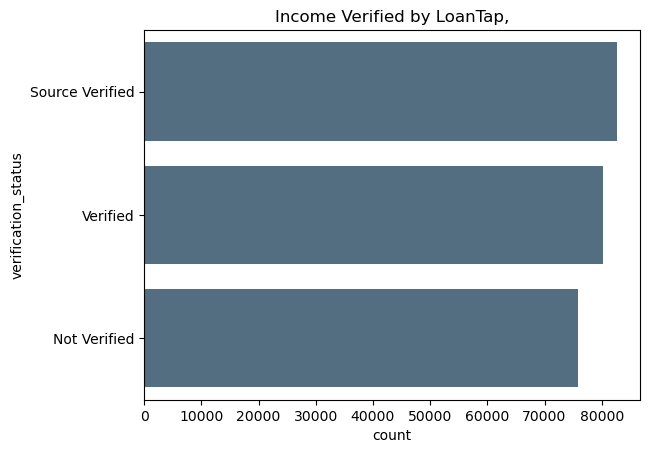

,Count,Prob
verification_status,,
Source Verified,82588,0.346220
Verified,80139,0.335953
Not Verified,75815,0.317827


In [29]:
cat_eda(X_train['verification_status'], 'Income Verified by LoanTap,')

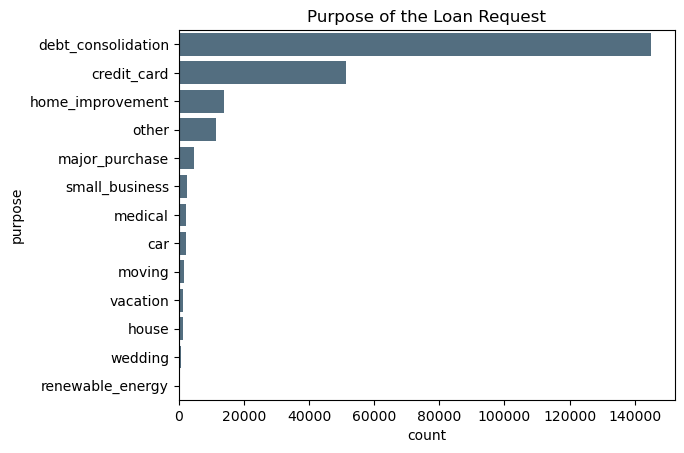

,Count,Prob
purpose,,
debt_consolidation,145041,0.608031
credit_card,51359,0.215304
home_improvement,14017,0.058761
other,11484,0.048142
major_purchase,4566,0.019141
small_business,2640,0.011067
medical,2293,0.009613
car,2201,0.009227
moving,1546,0.006481


In [30]:
cat_eda(X_train['purpose'], 'Purpose of the Loan Request')

The categories *renewable_energy*, *wedding*, *house*, *vacation*, *moving*, *car*, *medical*, *small_business* and *major_purchase* are relatively underrepresented in the dataset. To avoid creating sparse dummy variables, I will combine them into a single category *consumer needs*.

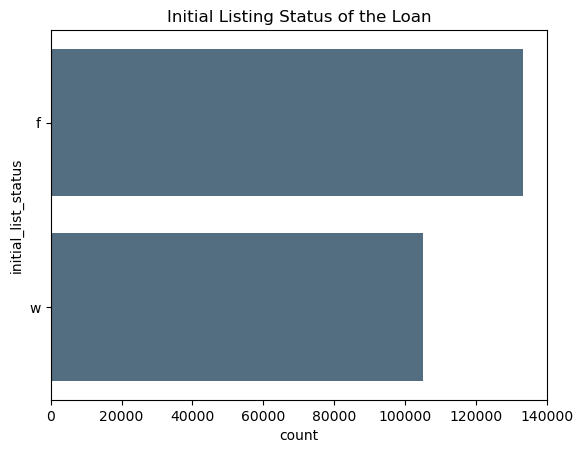

,Count,Prob
initial_list_status,,
f,133344,0.558996
w,105198,0.441004


In [31]:
cat_eda(X_train['initial_list_status'], 'Initial Listing Status of the Loan')

## 3. Checking Predictors on Complete and Quazi-Complete Separation
I will examine the variables for complete or quasi-complete separation to identify any potential perfect predictors.
https://stats.oarc.ucla.edu/other/mult-pkg/faq/general/faqwhat-is-complete-or-quasi-complete-separation-in-logisticprobit-regression-and-how-do-we-deal-with-them/

In [15]:
train = pd.concat([y_train, X_train], axis=1)
train.head()

,loan_status,loan_amnt,int_rate,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies,delta_issue_earliest,term,emp_length,home_ownership,verification_status,purpose,initial_list_status
314114,0,25000.0,19.20,153000.0,6.39,9.0,0.0,25599.0,49.6,21.0,1.0,0.0,3287,60 months,8 years,MORTGAGE,Verified,debt_consolidation,f
36249,1,5000.0,13.67,43763.0,6.23,14.0,1.0,6784.0,45.8,38.0,0.0,1.0,8097,36 months,10+ years,OWN,Not Verified,car,w
6840,0,20000.0,9.67,90000.0,11.36,16.0,0.0,5295.0,26.3,22.0,0.0,0.0,4536,36 months,3 years,RENT,Verified,debt_consolidation,f
81381,0,9550.0,17.57,55000.0,24.85,9.0,0.0,7840.0,80.0,21.0,3.0,0.0,5479,36 months,4 years,MORTGAGE,Not Verified,debt_consolidation,f
245250,0,20125.0,23.50,45000.0,29.71,14.0,1.0,13977.0,83.7,37.0,2.0,1.0,10074,60 months,2 years,OWN,Verified,credit_card,f


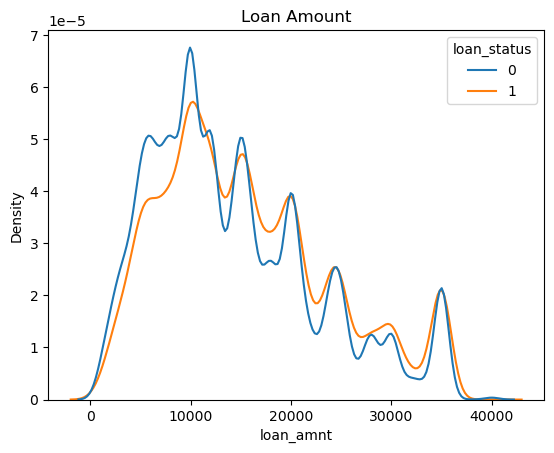

In [130]:
sep_check(train, 'loan_amnt', 'loan_status', 'Loan Amount')

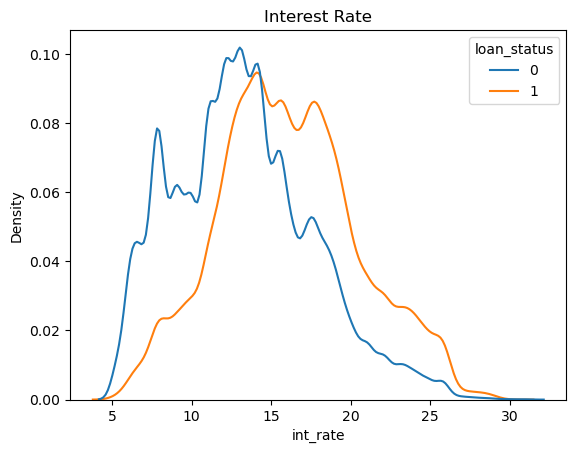

In [131]:
sep_check(train, 'int_rate', 'loan_status', 'Interest Rate')

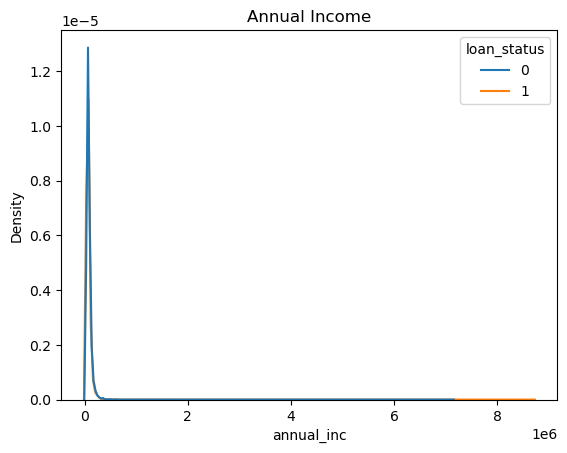

In [132]:
sep_check(train, 'annual_inc', 'loan_status', 'Annual Income')

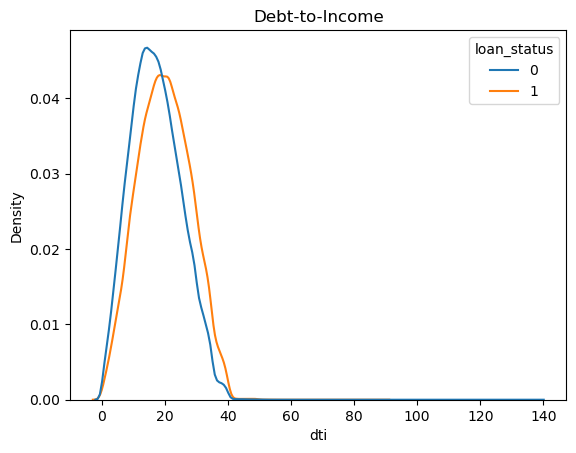

In [133]:
sep_check(train, 'dti', 'loan_status', 'Debt-to-Income')

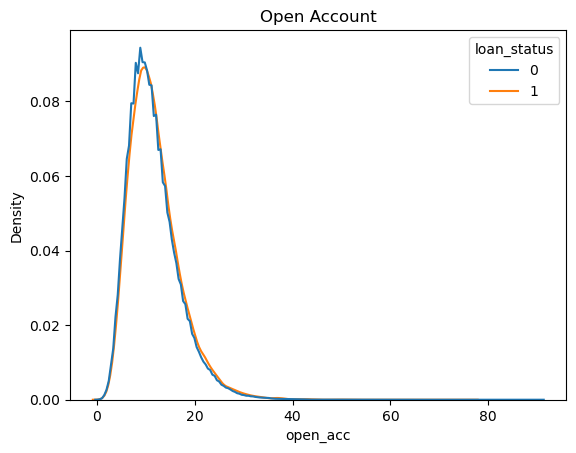

In [134]:
sep_check(train, 'open_acc', 'loan_status', 'Open Account')

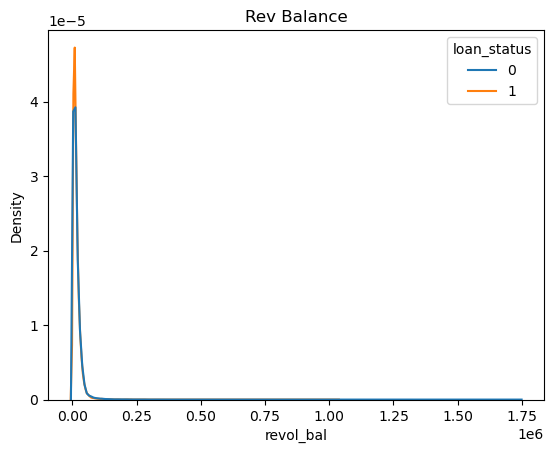

In [135]:
sep_check(train, 'revol_bal', 'loan_status', 'Rev Balance')

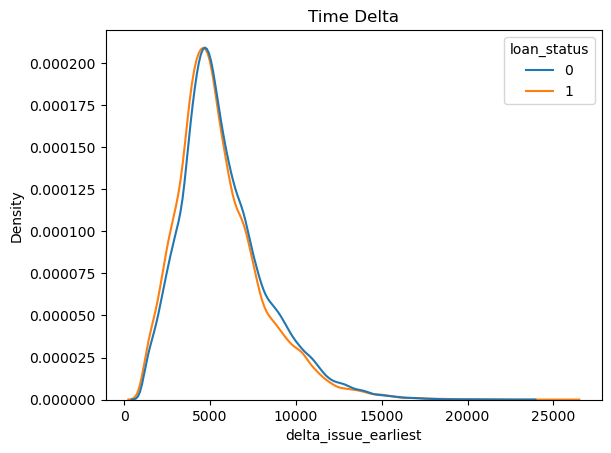

In [136]:
sep_check(train, 'delta_issue_earliest', 'loan_status', 'Time Delta')

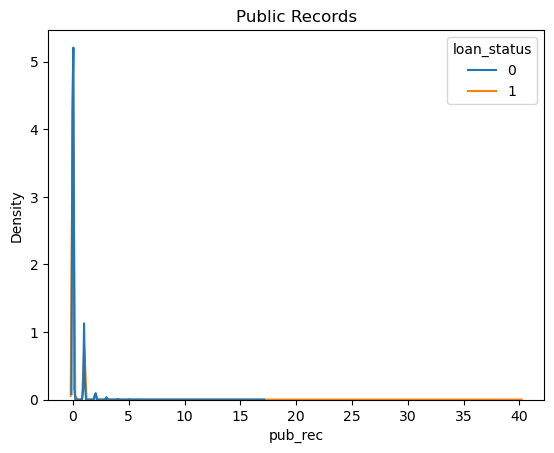

In [137]:
sep_check(train, 'pub_rec', 'loan_status', 'Public Records')

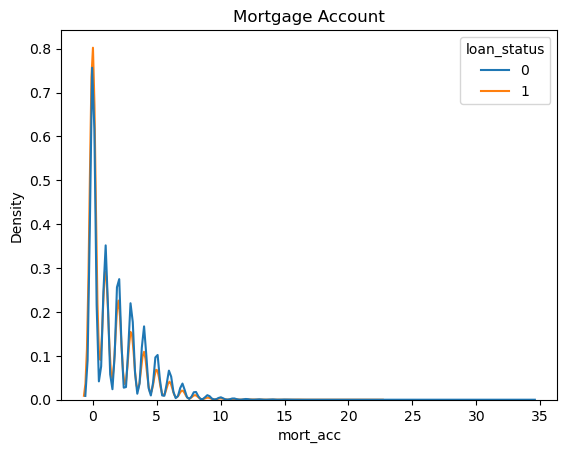

In [138]:
sep_check(train, 'mort_acc', 'loan_status', 'Mortgage Account')

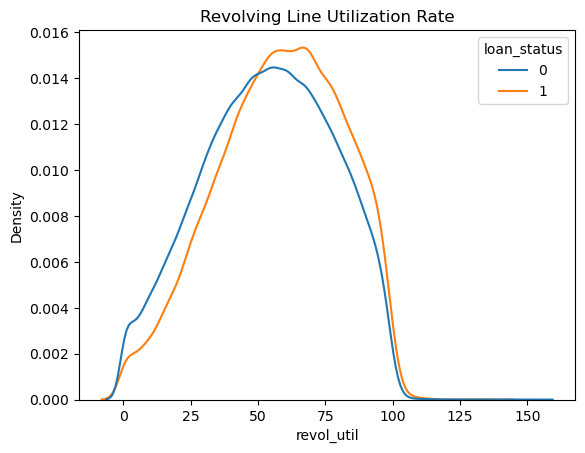

In [33]:
sep_check(train, 'revol_util', 'loan_status', 'Revolving Line Utilization Rate')

## 4. Conclusion

Based on the exploratory data analysis (EDA) above, the following data preprocessing steps have been identified:

1. Log transformation of the variables:  *annual_inc*, *revol_bal*, *delta_issue_earliest*
2. Combine the *Other*, *None* and *Any* categories into a single category for *home_ownership*
3. Group the *renewable energy*, *wedding*, *house*, *vacation*, *moving*, *car*, *medical*, *small_business* and *major_purchase* categories under a single *consumer needs* category for *purpose*
4. Group the *emp_length* into the larger buckets: ≤2 years of experience, 3–5 years, 6–9 years and 10+ years
5. Convert *mort_acc*, *pub_rec* and *pub_rec_bankruptcies* into binary variables. 
6. Apply one-hot encoding to the categorical variables

No apparent signs of complete or quasi-complete separation were identified among the numerical variables; therefore, no variables need to be excluded on this basis. Among the predictors, int_rate appears to be the strongest candidate based on the class separation observed in the distribution plots.

In [26]:
validation = pd.concat([y_val, X_val], axis=1)
test = pd.concat([y_test, X_test], axis=1)

In [29]:
train.to_csv('train.csv', sep=',', index=False)
validation.to_csv('validation.csv', sep=',', index=False)
test.to_csv('test.csv', sep=',', index=False)